# Medium-sized Inversions
Here, we visualize the inversions that were identified for the `medium` treatment across the range of depths.

In [ ]:
library(ggplot2)

read_data <- function(size_treatment, depth){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(
        paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
        header = T
    )[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    pooled_inversions$sample <- paste("pooled", depth, size_treatment, sep = "_")

    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}

plot_data <- function(data, size_treatment, depth){
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        labs(title = "Called Inversions", subtitle = paste(size_treatment, depth), x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

Set a global variable `.size` to `"medium"` to avoid writing it each time

In [25]:
.size <- "medium"

## 0.5X depth

In [26]:
depth_05X <- read_data(.size, "05X")
depth_05X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,1591146,1776073,simulated_inversions
2L,6436329,6636405,simulated_inversions
2L,17056243,17424245,simulated_inversions
2L,20404853,20474308,simulated_inversions
2R,9640874,9978281,simulated_inversions
2R,15862083,16302028,simulated_inversions
2R,17910285,18000549,simulated_inversions
2R,18236490,18696638,simulated_inversions
3R,16760480,16905871,simulated_inversions


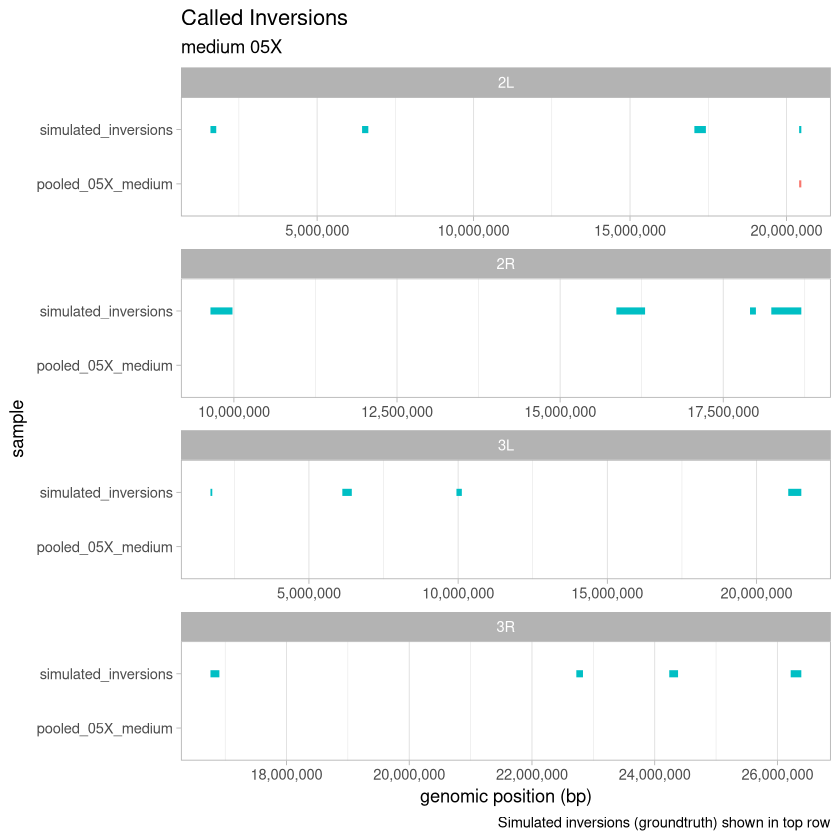

In [27]:
plot_data(depth_05X, .size, "05X")

## 2X Depth

In [29]:
depth_2X <- read_data(.size, "2X")
depth_2X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,1591146,1776073,simulated_inversions
2L,6436329,6636405,simulated_inversions
2L,17056243,17424245,simulated_inversions
2L,20404853,20474308,simulated_inversions
2R,9640874,9978281,simulated_inversions
2R,15862083,16302028,simulated_inversions
2R,17910285,18000549,simulated_inversions
2R,18236490,18696638,simulated_inversions
3R,16760480,16905871,simulated_inversions


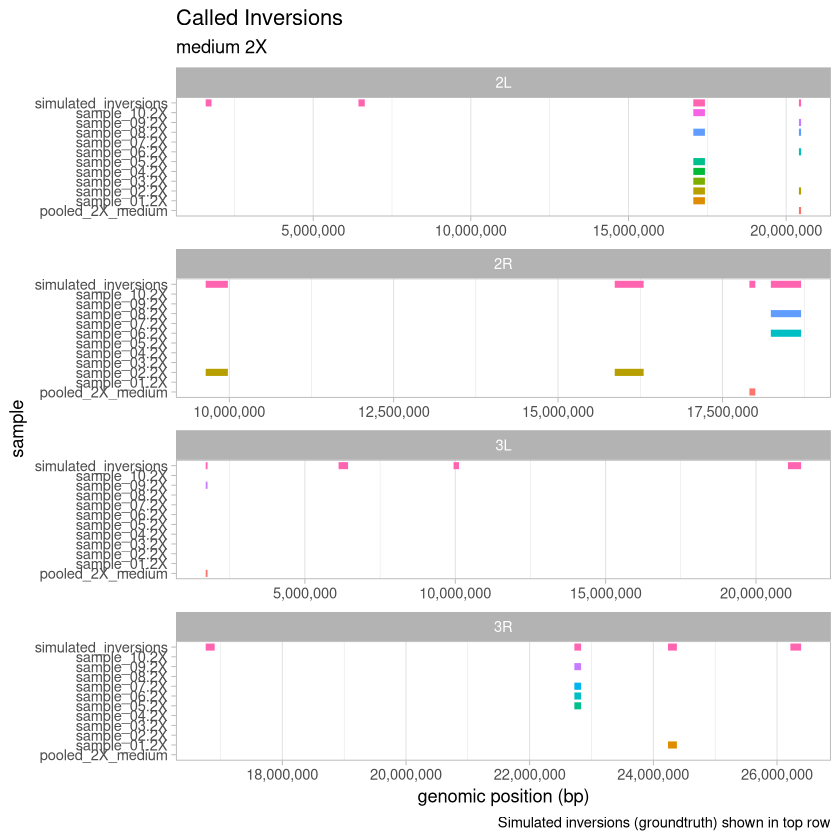

In [30]:
plot_data(depth_2X, .size, "2X")

## 5X Depth

In [31]:
depth_5X <- read_data(.size, "5X")
depth_5X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,1591146,1776073,simulated_inversions
2L,6436329,6636405,simulated_inversions
2L,17056243,17424245,simulated_inversions
2L,20404853,20474308,simulated_inversions
2R,9640874,9978281,simulated_inversions
2R,15862083,16302028,simulated_inversions
2R,17910285,18000549,simulated_inversions
2R,18236490,18696638,simulated_inversions
3R,16760480,16905871,simulated_inversions


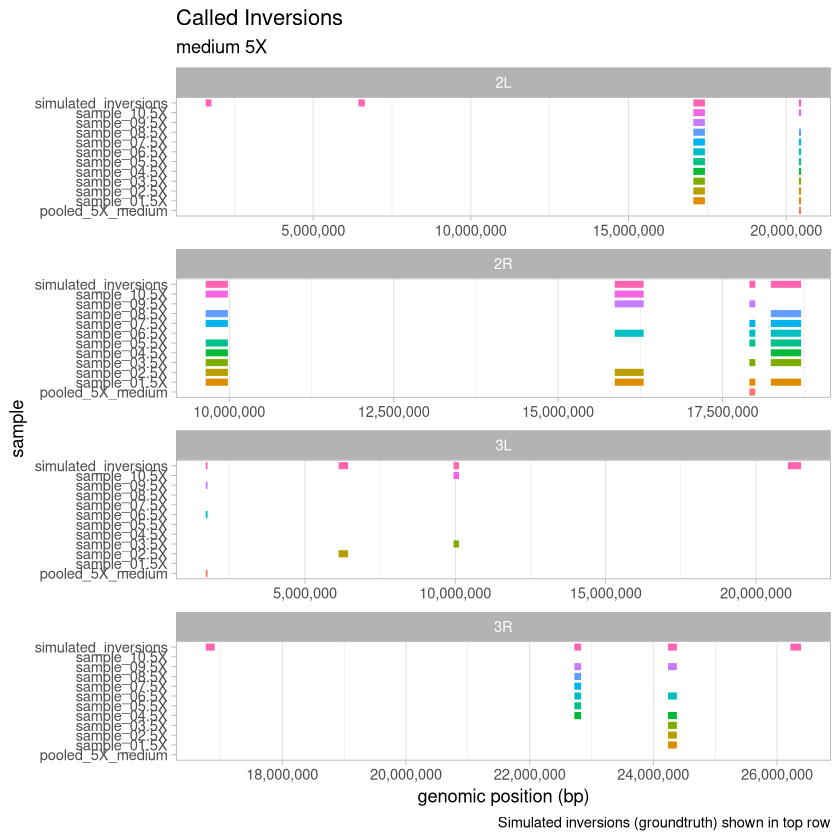

In [32]:
plot_data(depth_5X, .size, "5X")

## 10X Depth

In [33]:
depth_10X <- read_data(.size, "10X")
depth_10X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,1591146,1776073,simulated_inversions
2L,6436329,6636405,simulated_inversions
2L,17056243,17424245,simulated_inversions
2L,20404853,20474308,simulated_inversions
2R,9640874,9978281,simulated_inversions
2R,15862083,16302028,simulated_inversions
2R,17910285,18000549,simulated_inversions
2R,18236490,18696638,simulated_inversions
3R,16760480,16905871,simulated_inversions


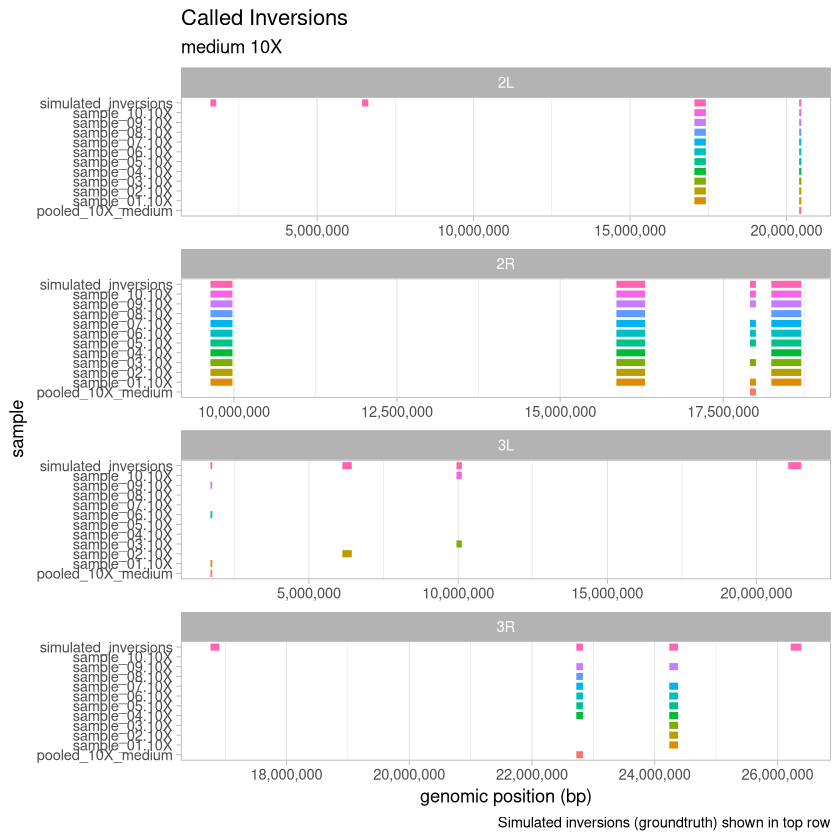

In [34]:
plot_data(depth_10X, .size, "10X")

## 20X Depth

In [35]:
depth_20X <- read_data(.size, "20X")
depth_20X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,1591146,1776073,simulated_inversions
2L,6436329,6636405,simulated_inversions
2L,17056243,17424245,simulated_inversions
2L,20404853,20474308,simulated_inversions
2R,9640874,9978281,simulated_inversions
2R,15862083,16302028,simulated_inversions
2R,17910285,18000549,simulated_inversions
2R,18236490,18696638,simulated_inversions
3R,16760480,16905871,simulated_inversions


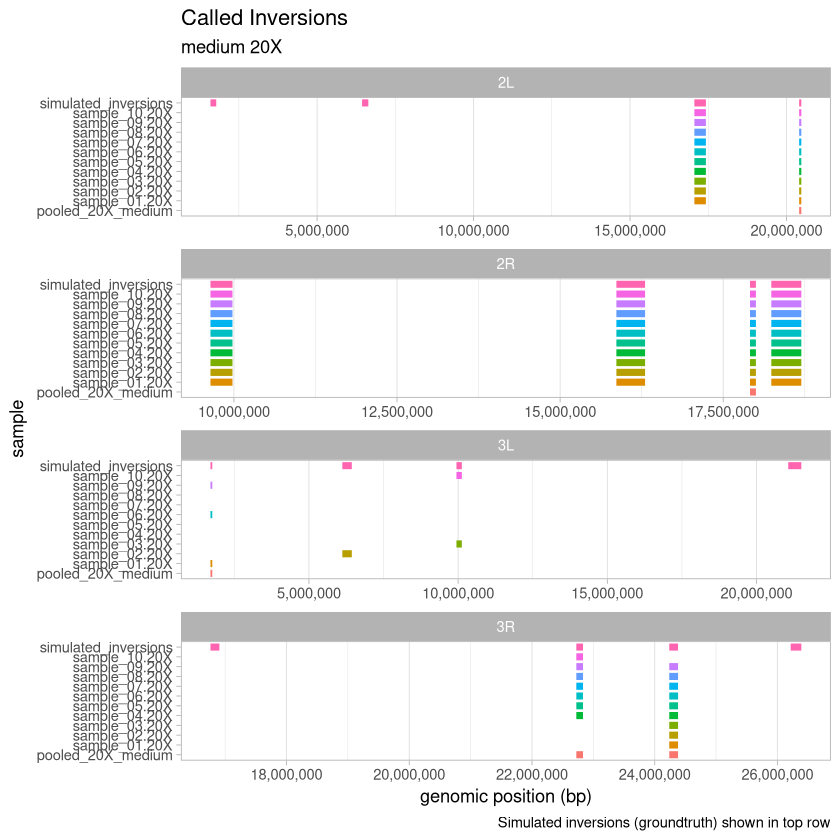

In [36]:
plot_data(depth_20X, .size, "20X")